# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np # importar librerías

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [3]:
plans.head(5) # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head(5) # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head(5) # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info() # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info() # inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info() # inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

## 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum()) # Cantidad de valores nulos
print()
print(users.isna().mean()) # Proporción de valores nulos

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum()) # Cantidad de valores nulos
print()
print(usage.isna().mean()) # Proporción de valores nulos

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

## Analisis

📁 users.csv

Columnas con nulos:

city (11.7%)
Tipo: MAR
Acción: Imputar como “Unknown”, ya que el porcentaje es moderado y no conviene eliminar usuarios.

churn_date (88.35%)
Tipo: MNAR
Acción: No imputar; los nulos indican clientes activos, se recomienda convertir en variable binaria de churn.

📁 usage.csv

Columnas con nulos:

date (0.12%)
Tipo: MCAR
Acción: Eliminar filas, ya que el porcentaje es mínimo y la fecha es un dato clave.

duration (55.19%)
Tipo: MAR
Acción: No imputar; los nulos dependen del tipo de evento (text) donde no aplica duración.

length (44.74%)
Tipo: MAR
Acción: No imputar; los nulos dependen del tipo de evento (call) donde no aplica longitud.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.

El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna user_id no presenta valores inválidos; los IDs están dentro de un rango coherente y no muestran anomalías.
  
- La columna age presenta un valor mínimo de -999, lo cual es imposible para una edad; este valor corresponde a un sentinel que representa dato faltante y debe reemplazarse por NaN.

In [13]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- La columna id no presenta valores inválidos; los valores están dentro del rango esperado y son coherentes.

- La columna user_id muestra un rango consistente con el dataset de usuarios y no presenta anomalías evidentes.

- La columna duration no presenta valores negativos; el mínimo es 0 (posibles llamadas fallidas) y el máximo es 120 minutos, lo cual es razonable.

- La columna length no presenta valores negativos; el mínimo es 0 y el máximo es 1490 caracteres, lo cual es alto pero posible en mensajes largos, por lo que no se identifican sentinels evidentes.

In [14]:
# explorar columnas categóricas de users
for col in ['city', 'plan']:
    print(f"\nColumna: {col}")
    print(users[col].value_counts(dropna=False))


Columna: city
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Columna: plan
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna city presenta varias ciudades válidas y 469 valores nulos previamente identificados; además, se observan 96 registros con el valor "?", lo cual corresponde a un sentinel que representa información faltante y debe reemplazarse por NaN.

- La columna plan contiene únicamente las categorías "Basico" y "Premium", sin valores nulos ni categorías inconsistentes, por lo que no se identifican valores inválidos.

In [15]:
# explorar columna categórica de usage
print(usage['type'].value_counts(dropna=False)) # completa el código

text    22092
call    17908
Name: type, dtype: int64


- La columna type contiene únicamente las categorías "text" y "call", sin valores nulos ni categorías inconsistentes, por lo que no se identifican valores inválidos ni sentinels.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

## Analisis

Se identificaron valores inválidos en las siguientes columnas:

age: Se encontró el valor -999, que corresponde a un sentinel utilizado para representar datos faltantes.
Acción: Reemplazar -999 por NaN para tratarlo como valor faltante.

city: Se identificaron 96 registros con el valor "?", que funciona como sentinel para información desconocida.
Acción: Reemplazar "?" por NaN para unificar los valores faltantes.

En las demás columnas numéricas (user_id, id, duration, length) no se detectaron valores negativos inválidos ni sentinels evidentes.

En las columnas categóricas plan y type no se encontraron categorías inconsistentes ni valores inválidos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"], errors="coerce") # completa el código

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"], errors="coerce") # completa el código

In [18]:
# Revisar los años presentes en `reg_date` de users
users["reg_date"].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

Al revisar los años presentes en la columna reg_date, se identificaron registros correspondientes a 2022, 2023 y 2024, que están dentro del rango esperado. Sin embargo, se encontraron 40 registros con año 2026, lo cual representa fechas futuras y un posible error de captura. Se recomienda revisar estos registros y corregirlos o convertirlos en NaT si no es posible validarlos.

In [19]:
# Revisar los años presentes en `date` de usage
usage["date"] = pd.to_datetime(usage["date"], errors="coerce")
usage["date"].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En date, todos los registros corresponden al año 2024, lo cual está dentro del rango esperado de datos disponibles (hasta 2024). No se identifican años futuros ni fuera de rango, por lo que no se detectan errores de captura en esta columna. Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

## Analisis 

Se identificaron fechas fuera de rango en la columna reg_date, donde aparecen 40 registros correspondientes al año 2026, lo cual es un año futuro considerando que los datos están disponibles hasta 2024. Esto indica un posible error de captura.

No se encontraron años imposibles en la columna date de usage, ya que todos los registros corresponden a 2024, dentro del rango esperado.

Acción recomendada: Revisar los registros con año 2026 y, si no es posible validarlos, convertirlos en NaT o corregir el año para mantener la consistencia del dataset.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
users['age'] = users['age'].replace(-999, np.nan)
age_mediana = users['age'].median() 
users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', np.nan)

# Verificar
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [22]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

# Marcar fechas futuras como NaN (mayores a 2024)
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = np.nan

# Verificar años nuevamente
users['reg_date'].dt.year.value_counts(dropna=False)

2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
def contar_nulos(grupo):
    return grupo.isnull().sum()

print(usage.groupby('type')[['duration', 'length']].apply(contar_nulos))

usage.loc[usage['type'] == 'text', 'duration'] = np.nan
usage.loc[usage['type'] == 'call', 'length'] = np.nan

      duration  length
type                  
call         0   17896
text     22076       0


In [24]:
# Verificación MAR en usage (Missing At Random) para length
def verificar_mar(df):
    return df.isnull().sum()

analisis_length = usage.groupby('type')[['length']].apply(verificar_mar)

print("Verificación de nulos en la columna 'length' según el tipo de servicio:")
print(analisis_length)

Verificación de nulos en la columna 'length' según el tipo de servicio:
      length
type        
call   17908
text       0


### Diagnóstico: 
Tras el análisis de los datos mediante una función de conteo agrupada por el tipo de servicio (type), se determinó que los valores nulos en las columnas duration y length no son errores de captura, sino que se clasifican como Missing At Random (MAR).

### Evidencia:

Columna length: Presenta nulos únicamente en los registros de tipo call. Esto es correcto, ya que las llamadas telefónicas no poseen una longitud de caracteres de texto.

Columna duration: Presenta nulos únicamente en los registros de tipo text. Esto es correcto, ya que los mensajes de texto no tienen una duración medida en minutos.

### Conclusión y Acción:
Dado que la falta de datos está vinculada sistemáticamente a la naturaleza del servicio (voz vs. texto), se decide mantener los valores como nulos (NaN). Imputar estos valores con ceros o promedios introduciría un sesgo artificial en el análisis, afectando el cálculo real de los promedios de consumo de cada servicio.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg.columns = ['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


###  4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
print("Resumen estadístico de consumos y edad:")
print(users[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe())

Resumen estadístico de consumos y edad:
               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     48.136000       5.524381       4.478120             22.836934
std      17.689919       2.358416       2.144238             16.590213
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.095000
50%      48.000000       5.000000       4.000000             19.740000
75%      63.000000       7.000000       6.000000             31.185000
max      79.000000      17.000000      15.000000            155.690000


In [29]:
# Distribución porcentual del tipo de plan
print("\nDistribución porcentual de los planes:")
print(users['plan'].value_counts(normalize=True) * 100)


Distribución porcentual de los planes:
Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

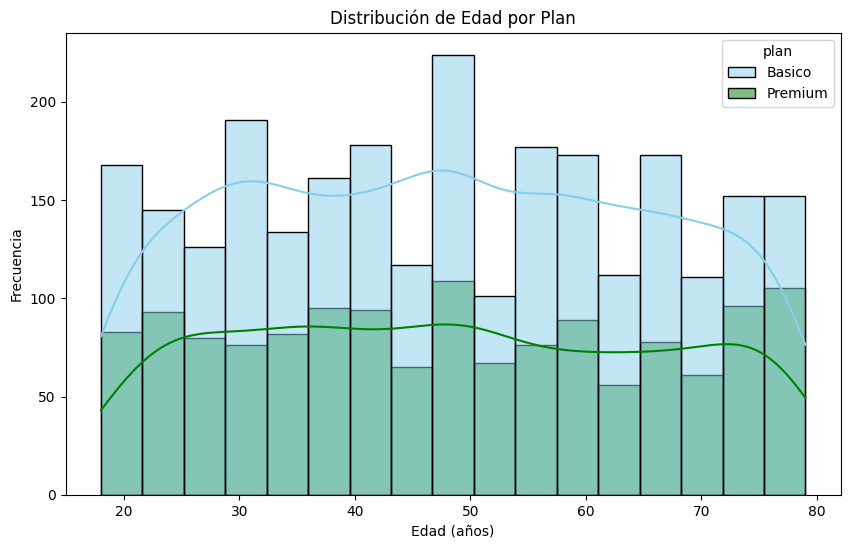

In [30]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(10, 6))
sns.histplot(data=users, x='age', hue='plan', palette=['skyblue', 'green'], kde=True)

plt.title('Distribución de Edad por Plan')
plt.xlabel('Edad (años)')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 

- Patrón: La edad de los usuarios parece estar distribuida de manera bastante uniforme a lo largo de los diferentes rangos, lo que indica que no existe un patrón donde un plan específico sea preferido por jóvenes o adultos mayores. Ambos planes tienen una base de usuarios con edades muy variadas.

- Distribución: Es una distribución casi simétrica o uniforme, ya que no presenta un pico pronunciado ni una "cola" larga hacia un extremo. Esto sugiere que la edad no es el factor determinante para elegir entre el plan Básico o Premium.

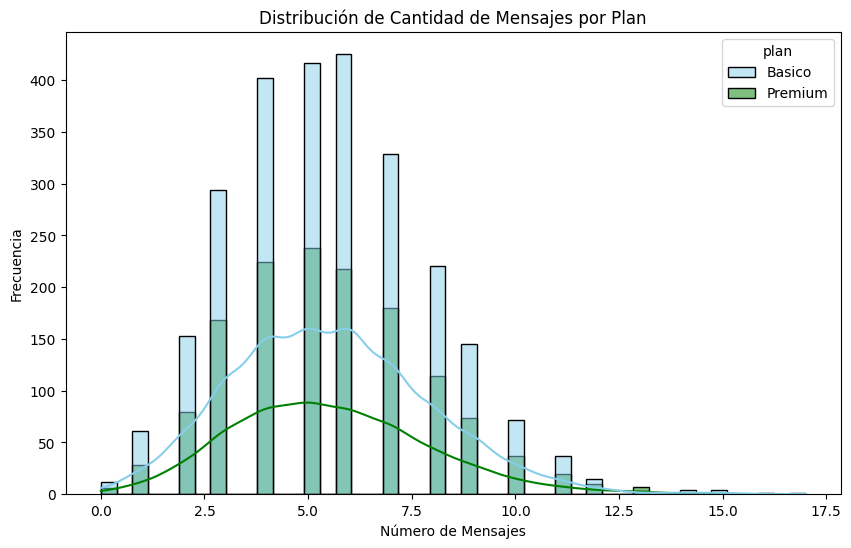

In [31]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(10, 6))
sns.histplot(data=users, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], kde=True)

plt.title('Distribución de Cantidad de Mensajes por Plan')
plt.xlabel('Número de Mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 

- Patrón: Los usuarios del plan Básico están muy concentrados en el rango de 0 a 20 mensajes. En cambio, el plan Premium tiene una distribución más "estirada", lo que significa que sus usuarios se sienten con más libertad de enviar mensajes sin preocuparse por el límite.

- Distribución: Es una distribución sesgada a la derecha (o sesgo positivo). La mayoría de los datos se amontonan a la izquierda y la "cola" del gráfico se alarga hacia la derecha.

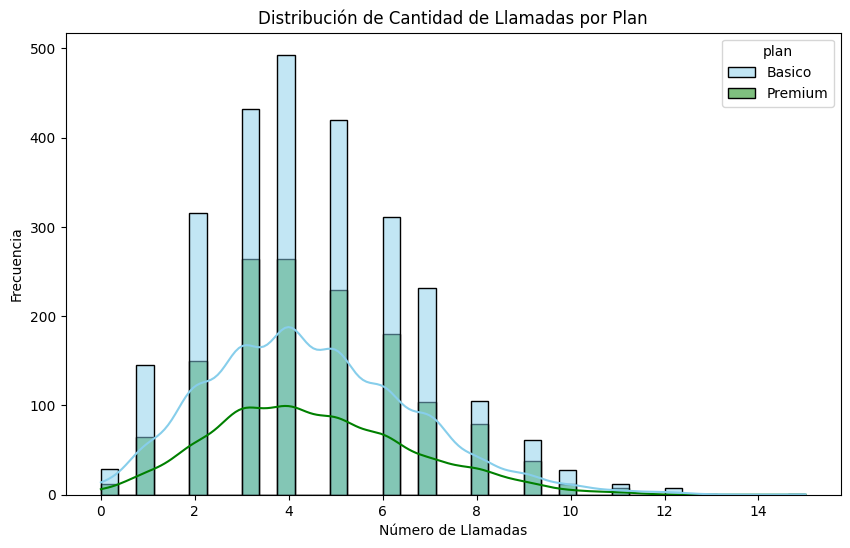

In [32]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(10, 6))
sns.histplot(data=users, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], kde=True)

plt.title('Distribución de Cantidad de Llamadas por Plan')
plt.xlabel('Número de Llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 

- Patrón: Ambos planes muestran un comportamiento muy similar en cuanto a la frecuencia; el pico de usuarios (la parte más alta de la campana) se encuentra entre las 40 y 60 llamadas. No existe un patrón que distinga drásticamente a un usuario Premium de uno Básico solo por el número de veces que marca un número.

- Distribución: Es una distribución simétrica (con forma de campana o Normal). Los datos se agrupan de forma equilibrada alrededor del promedio, con pocos usuarios haciendo muy pocas o muchísimas llamadas.

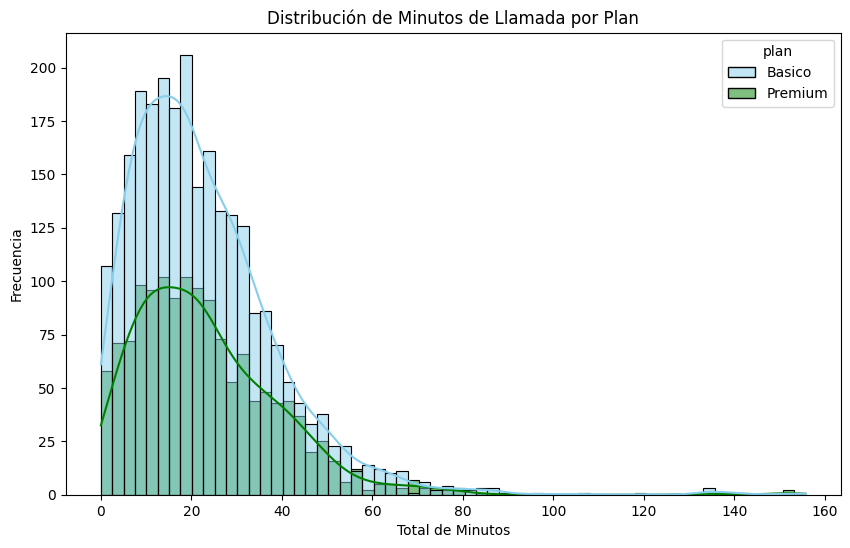

In [33]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(10, 6))
sns.histplot(data=users, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'], kde=True)

plt.title('Distribución de Minutos de Llamada por Plan')
plt.xlabel('Total de Minutos')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Patrón de Consumo: Se observa que la gran mayoría de los usuarios, independientemente de su plan, concentran su consumo en el rango de 10 a 40 minutos. El plan Básico presenta picos de frecuencia más altos, lo que es consistente con su mayor volumen de usuarios (64.8%).

- Distribución: La variable presenta una distribución sesgada a la derecha (sesgo positivo). Esto se debe a que, mientras la mayoría de los usuarios se agrupan en valores bajos, existe una "cola" que se extiende hacia la derecha (hasta los 160 minutos), causada por un grupo reducido de usuarios con consumos excepcionalmente altos.

- Comparación entre Planes: No se aprecia una separación drástica en el comportamiento de uso entre planes; ambos siguen una tendencia similar, aunque los usuarios Premium muestran una dispersión ligeramente mayor en la base de la campana.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

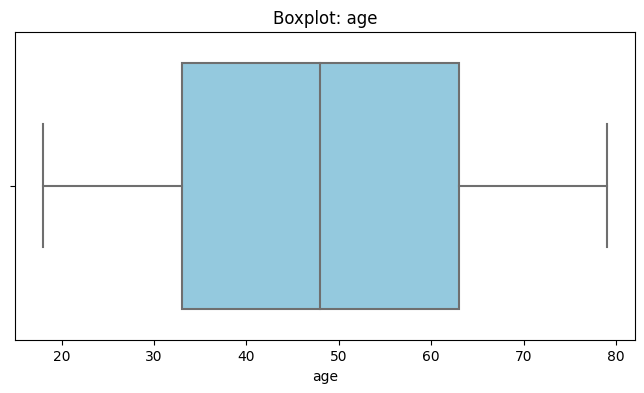

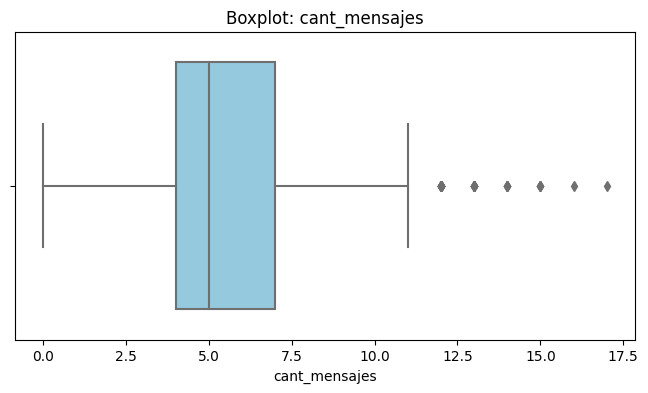

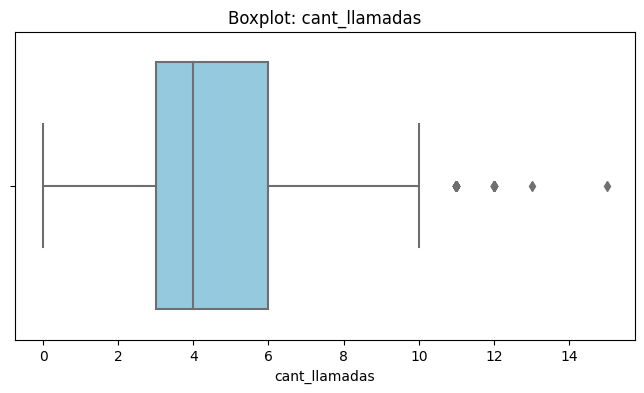

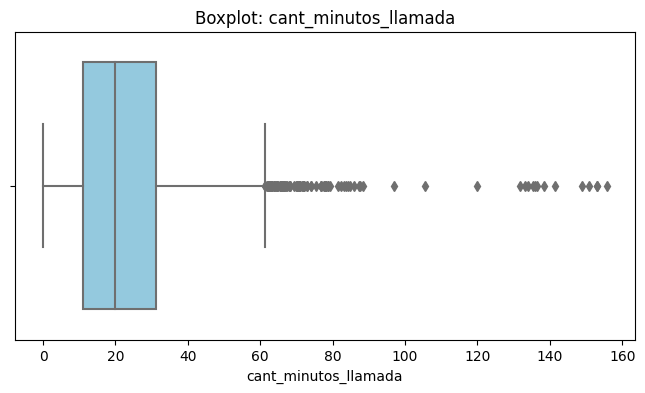

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=users[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 

- age: No presenta outliers. Los datos se mantienen dentro de los bigotes del boxplot, lo que indica que la edad de los usuarios es consistente y no hay valores imposibles o extraños.

- cant_mensajes: Sí presenta outliers. Hay varios puntos a la derecha del límite superior, lo que indica un grupo de usuarios que envía muchos más mensajes que el promedio.

- cant_llamadas: Sí presenta outliers. Se observan valores atípicos en el extremo superior, representando a usuarios con una frecuencia de llamadas muy alta.

- cant_minutos_llamada: Sí presenta outliers. Al igual que en las llamadas, existen usuarios con consumos de tiempo muy elevados que se alejan del comportamiento de la mayoría.

In [35]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

print("--- Análisis de Outliers (Solo Límite Superior) ---")

for col in columnas_limites:
    Q1 = users[col].quantile(0.25)
    Q3 = users[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Calculamos SOLO el límite superior (Q3 + 1.5 * IQR)
    limite_superior = Q3 + 1.5 * IQR
    
    # Identificamos cuántos usuarios superan ese límite
    outliers_count = len(users[users[col] > limite_superior])
    
    print(f"Columna: {col}")
    print(f"  Límite Superior: {limite_superior:.2f}")
    print(f"  Cantidad de outliers: {outliers_count}")
    print("-" * 35)

--- Análisis de Outliers (Solo Límite Superior) ---
Columna: cant_mensajes
  Límite Superior: 11.50
  Cantidad de outliers: 46
-----------------------------------
Columna: cant_llamadas
  Límite Superior: 10.50
  Cantidad de outliers: 30
-----------------------------------
Columna: cant_minutos_llamada
  Límite Superior: 61.32
  Cantidad de outliers: 96
-----------------------------------


In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,22.836934
std,2.358416,2.144238,16.590213
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.095000
50%,5.000000,4.000000,19.740000
75%,7.000000,6.000000,31.185000
max,17.000000,15.000000,155.690000


💡Insights: 

- cant_mensajes. Decisión: Mantener.¿Por qué?: Aunque el límite superior es bajo ($11.5$ mensajes) y el máximo es solo $17$, estos usuarios representan un comportamiento real. En planes con límites de SMS, estos pocos usuarios que se exceden generan ingresos marginales. Al ser una cantidad pequeña de mensajes, no distorsionan gravemente el promedio, pero sí reflejan la diversidad de uso.
- cant_llamadas. Decisión: Mantener.¿Por qué?: Los $30$ outliers detectados (quienes hacen más de $10.5$ llamadas) son clientes activos. Eliminar a los usuarios que más utilizan el servicio telefónico nos daría una visión falsa de que el servicio se usa menos de lo que realmente se usa. Es un comportamiento de consumo válido, no un error de sistema.
- cant_minutos_llamada. Decisión: Mantener (Crítico).¿Por qué?: Esta es la variable más importante. Tenemos un máximo de $155.69$ minutos frente a un promedio de $22.83$. Estos $96$ usuarios son "Heavy Users".Si los eliminamos, estaríamos borrando a los clientes que más pagan por excedentes. El análisis de rentabilidad fallaría porque ignoraría a la sección de la población que más ingresos genera por minuto adicional.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [42]:
# Crear columna grupo_uso
def clasificar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

print(user_profile['grupo_uso'].value_counts())

Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64


In [43]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [45]:
# Crear columna grupo_edad
def clasificar_edad(age):
    if age < 30:
        return 'Joven'
    elif age < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile['age'].apply(clasificar_edad)

print(user_profile['grupo_edad'].value_counts())

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64


In [46]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

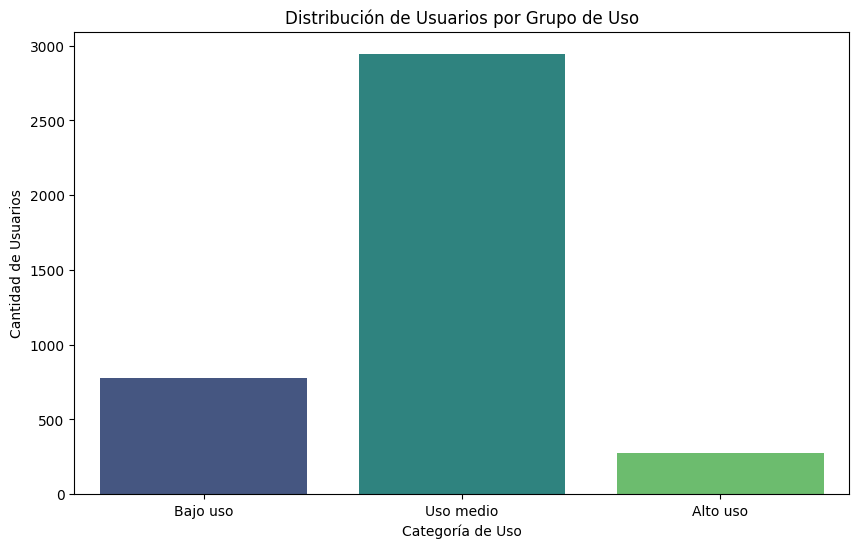

In [47]:
# Visualización de los segmentos por uso
plt.figure(figsize=(10, 6))
sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso', 'Uso medio', 'Alto uso'], palette='viridis')
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Categoría de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

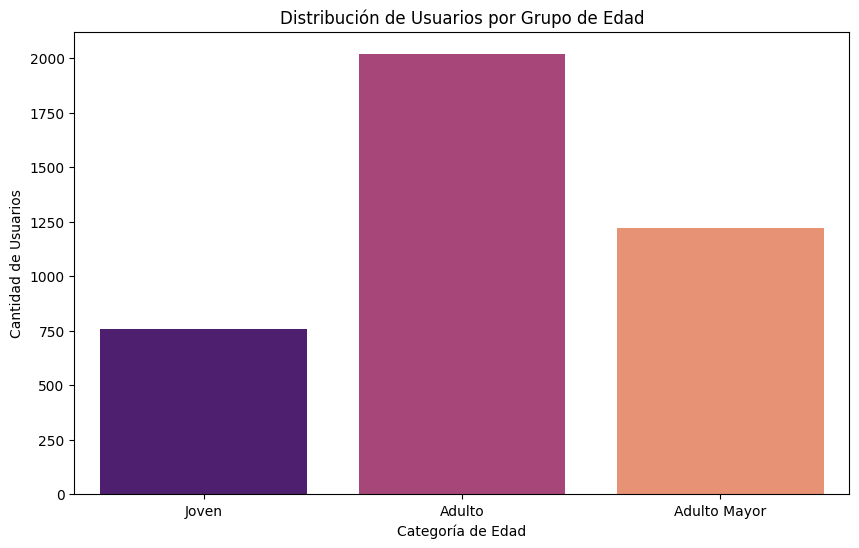

In [48]:
# Visualización de los segmentos por edad
plt.figure(figsize=(10, 6))
sns.countplot(data=user_profile, x='grupo_edad', order=['Joven', 'Adulto', 'Adulto Mayor'], palette='magma')
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Categoría de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show() 


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

### Columna age:

Problema detectado: Se encontró el valor sentinel -999.
Impacto: Afectaba múltiples registros (los que contenían -999).
Distorsionaba métricas como la media (33.7 inicialmente) y la desviación estándar (123), generando una distribución irreal.
Acción tomada: Se reemplazó -999 por NaN.
Posteriormente se imputaron los valores faltantes usando la mediana (48 años) para mantener la robustez estadística.

### Columna city: 

Problema detectado: Se encontraron valores inválidos representados como '?', además de valores faltantes (NaN).
Impacto: 96 registros contenían '?'. 469 registros ya estaban como NaN.
En total, 565 registros presentaban datos faltantes o inválidos en esta columna.
Acción tomada: Se reemplazó '?' por NaN para unificar los valores faltantes.
Se dejó la columna preparada para futura imputación o análisis categórico.

### Columna reg_date: 

Problema detectado: Se identificaron fechas correspondientes al año 2026, lo cual es inconsistente ya que el dataset solo contiene datos hasta 2024.
Impacto: 40 registros tenían fechas futuras, representaban un error de captura.
Acción tomada: Se convirtieron las fechas al tipo datetime con manejo de errores.
Se marcaron las fechas mayores a 2024 como NaN.

### Columna usage.date

Problema detectado: No se encontraron años fuera de rango. Todos los registros corresponden al año 2024.
Acción tomada: No fue necesaria ninguna corrección.

🔍 **Segmentos por Edad**

Joven (< 30 años): Un segmento con potencial de crecimiento, aunque más propenso a preferir datos sobre voz.

Adulto (30-59 años): Es el segmento núcleo. Son los más numerosos y presentan el comportamiento de consumo más predecible y constante.

Adulto Mayor (≥ 60 años): Un grupo leal con patrones de uso más tradicionales y menos propensos a generar consumos extremos.

📊 **Segmentos por Nivel de Uso**

Bajo Uso: Clientes con necesidades mínimas de comunicación (< 5 llamadas/mensajes).

Uso Medio: El segmento más estable, que utiliza el servicio de forma regular pero controlada (< 10 llamadas/mensajes).

Alto Uso: Usuarios intensivos que superan los umbrales estándar; este grupo es el que empuja la media de consumo de minutos hacia arriba.

➡️ Esto sugiere que: 

Los segmentos más valiosos son los Adultos de Alto Uso y los usuarios del Plan Premium.

Rentabilidad por Excedentes: Los usuarios de "Alto Uso" (especialmente los 96 identificados en minutos) son los que generan ingresos adicionales más allá de la renta básica.

Estabilidad Financiera: El segmento Adulto es valioso por su volumen; al ser la mayoría de la base de clientes, representan el ingreso mensual recurrente (MRR) más sólido de la compañía.

Eficiencia del Plan: Aquellos en el plan Premium son valiosos porque pagan una tarifa base más alta, lo que garantiza un margen de beneficio superior incluso si su consumo es moderado.

Encontramos outliers significativos principalmente en la duración de las llamadas (61.32 minutos como límite superior), donde algunos usuarios llegan hasta los 155.69 minutos.

Ingresos Extraordinarios: Para el negocio, estos outliers implican una fuente de facturación por "minutos adicionales" muy lucrativa, especialmente en el plan Básico.

Riesgo de Churn (Fuga): Estos clientes son vulnerables. Si un competidor les ofrece un plan "Ilimitado", podrían irse para evitar los cobros por excedentes de ConnectaTel.

Validación de Oferta: El hecho de que existan tantos usuarios superando los 60 minutos sugiere que hay una demanda no satisfecha. Implica que ConnectaTel podría beneficiarse de crear un plan intermedio o un "add-on" de minutos ilimitados para capturar ese valor de forma más segura.

💡 **Recomendaciones**

1. Lanzamiento de un "Plan Heavy User" o "Plan Pro": Detectamos que el límite superior normal es de 61.32 minutos, pero hay usuarios que llegan a 155 minutos.
Recomendación: Crear un plan que ofrezca minutos ilimitados o una bolsa de 200 minutos.
Objetivo: Evitar que los 96 "outliers" se fuguen a la competencia buscando tarifas planas, asegurando un ingreso fijo mensual más alto en lugar de depender de excedentes variables.

2. Rediseño del Plan Básico (Enfoque en Datos, no SMS): Vimos que el promedio de mensajes es muy bajo (5.5 mensajes) y el límite de outliers apenas llega a 11.5.
Recomendación: Reducir la importancia de los SMS en la publicidad del plan Básico y sustituirlos por un pequeño bono de datos o minutos.
Objetivo: Aumentar el valor percibido del plan para los Jóvenes y Adultos de Bajo Uso, quienes ya casi no utilizan la mensajería tradicional.

3. Programa de Lealtad para el Segmento "Adulto": Dado que el grupo de 30-59 años es tu base más sólida y numerosa:
Recomendación: Implementar beneficios por antigüedad o "familia" para este segmento.
Objetivo: Blindar el ingreso principal de la compañía (el MRR) ante ofertas agresivas de nuevos competidores.

4. Notificaciones de Consumo Inteligente: Muchos usuarios de Uso Medio podrían estar cerca de convertirse en outliers sin saberlo.
Recomendación: Enviar una notificación cuando alcancen el 80% de su límite (por ejemplo, al llegar a los 50 minutos) invitándolos a subir al siguiente plan con un descuento por los primeros 3 meses.
Objetivo: Realizar Upselling (migración a planes superiores) de forma orgánica y mejorar la experiencia del cliente al evitar sorpresas en su factura.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`